# Влияние распределения источника, объёма выборки и размера кодируемых блоков на эффективность кода Хаффмана

**Дисциплина:** Теория информации  
**Автор:** Дмитрий Багацкий  
**Формат:** исследовательская работа

## Аннотация

В работе экспериментально исследуется связь энтропии дискретного источника со средней длиной двоичного кода Хаффмана. Рассматриваются равномерные, геометрические, ципфовские и случайные распределения при разных размерах алфавита. Отдельно изучается статистическая цена построения кода по конечной выборке и роль аддитивного сглаживания. Для блоков длины от 1 до 4 сопоставляются выигрыш от уменьшения целочисленной избыточности и проигрыш из-за разреженности пространства блоков. На русских и английских текстах, программном коде и случайных байтах проверяется переносимость выводов на реальные данные. Полезная нагрузка отделяется от стоимости сериализации дерева, благодаря чему определяется практический порог окупаемости. Все алгоритмы реализованы самостоятельно, а таблицы, графики и выводы ниже получаются при полном воспроизводимом выполнении ноутбука без доступа к интернету.

## 1. Постановка задачи

**Цель:** определить, как форма распределения, мощность алфавита, объём обучающей выборки, длина блока и накладные расходы влияют на эффективность кода Хаффмана.

**Исследовательские вопросы.** Как форма распределения меняет выигрыш относительно фиксированного кода? Как быстро эмпирический код приближается к oracle-коду? Помогают ли блоки в пересчёте на исходный символ и способны ли большие блоки навредить при малой выборке? Когда экономия полезной нагрузки покрывает заголовок? Согласуются ли синтетические опыты с байтовым кодированием реальных текстов?

**Гипотезы.**

1. Для невырожденного источника $H(X)\le L<H(X)+1$.
2. Чем сильнее распределение отличается от равномерного, тем больше преимущество Хаффмана перед фиксированным кодом.
3. С ростом обучающей выборки средняя длина эмпирического кода приближается к oracle-коду.
4. При известных вероятностях блочное кодирование уменьшает верхнюю границу избыточности на символ до $1/m$.
5. При конечной выборке большой блок может ухудшить код из-за разреженности пространства блоков.
6. Для коротких сообщений заголовок может устранить выигрыш от сжатия.

**План.** Сначала проверяется реализация, затем проводятся четыре эксперимента: семейства распределений; оценивание по выборке; блоки; UTF-8 корпуса. Показатели: $H$, $L$, $R=L-H$, $\eta=H/L$, сумма Крафта, экономия относительно фиксированной длины, $\Delta L=L_{emp}-L_{oracle}$ и полный размер с заголовком. Генератор случайных чисел фиксирован: `seed=42`.

## 2. Теоретическая часть

Энтропия источника
$$H(X)=-\sum_{i=1}^{M}p_i\log_2p_i$$
есть средняя неопределённость на один символ. Для равномерного двоичного представления символа требуется
$$l_{\rm fixed}=\lceil\log_2M\rceil$$
бит. Префиксный код не допускает, чтобы одно кодовое слово было началом другого, поэтому поток декодируется однозначно слева направо. Его длины удовлетворяют неравенству Крафта
$$\sum_i2^{-l_i}\le1,$$
а средняя длина равна $L=\sum_i p_i l_i$.

Нижняя граница $H\le L$ следует из неравенства Крафта и оптимальности идеальных длин $-\log_2p_i$ среди вещественных длин. Верхняя граница получается, например, из кода Шеннона с целыми длинами $\lceil-\log_2p_i\rceil< -\log_2p_i+1$; Хаффман оптимален среди двоичных префиксных кодов и потому не хуже. Следовательно, для алфавита минимум из двух положительно вероятных символов
$$H(X)\le L<H(X)+1.$$
В техническом случае одного символа ниже назначается слово `0`; строгая граница в таком случае не заявляется.

Избыточность и эффективность:
$$R=L-H(X),\qquad \eta=\frac{H(X)}L.$$
Длины Хаффмана целочисленны, поэтому обычно нельзя достичь идеальных вещественных длин точно.

Для независимых блоков длины $m$ энтропия аддитивна:
$$H(X_1,\ldots,X_m)=mH(X).$$
Кодирование всех блоков даёт
$$mH(X)\le L_m<mH(X)+1,$$
то есть
$$H(X)\le\frac{L_m}{m}<H(X)+\frac1m.$$
Преимущество предполагает знание вероятностей блоков. При оценивании по данным число возможных блоков $M^m$ растёт экспоненциально, и многие блоки не наблюдаются.

In [1]:
import os, math, heapq, itertools, zlib, warnings
from collections import Counter
from dataclasses import dataclass

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-huffman-cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid", palette="colorblind")
PALETTE = sns.color_palette("colorblind")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
warnings.filterwarnings("error", category=RuntimeWarning)

## 3. Самостоятельная реализация кода Хаффмана

Узел хранит либо символ, либо двух потомков. Дополнительный счётчик в куче устраняет сравнение символов и обеспечивает устойчивость при равных весах. Нулевые веса допускаются: если полный алфавит задан, такие символы получают код и остаются кодируемыми.

In [2]:
@dataclass
class Node:
    symbol: object = None
    left: object = None
    right: object = None


def entropy(probabilities):
    p = np.asarray(list(probabilities), dtype=float)
    if np.any(p < 0) or not np.isclose(p.sum(), 1.0):
        raise ValueError("Вероятности должны быть неотрицательны и суммироваться в 1")
    positive = p[p > 0]
    return float(-np.sum(positive * np.log2(positive)))


def build_huffman_tree(weights):
    """weights: отображение symbol -> неотрицательный вес; нули сохраняются."""
    if not weights:
        raise ValueError("Алфавит пуст")
    heap, counter = [], itertools.count()
    for symbol, weight in weights.items():
        if weight < 0:
            raise ValueError("Вес не может быть отрицательным")
        heapq.heappush(heap, (float(weight), next(counter), Node(symbol=symbol)))
    if len(heap) == 1:
        return heap[0][2]
    while len(heap) > 1:
        w1, _, a = heapq.heappop(heap)
        w2, _, b = heapq.heappop(heap)
        heapq.heappush(heap, (w1 + w2, next(counter), Node(left=a, right=b)))
    return heap[0][2]


def build_codebook(tree):
    codes = {}
    def walk(node, prefix):
        if node.left is None and node.right is None:
            codes[node.symbol] = prefix or "0"  # технический односимвольный случай
            return
        if node.left is None or node.right is None:
            raise ValueError("Некорректное дерево")
        walk(node.left, prefix + "0")
        walk(node.right, prefix + "1")
    walk(tree, "")
    return codes


def encode(sequence, codebook):
    try:
        return "".join(codebook[x] for x in sequence)
    except KeyError as exc:
        raise ValueError(f"Символ {exc.args[0]!r} отсутствует в таблице") from exc


def decode(bits, tree):
    if any(bit not in "01" for bit in bits):
        raise ValueError("Битовая строка содержит не 0/1")
    if tree.left is None and tree.right is None:
        if any(bit != "0" for bit in bits):
            raise ValueError("Некорректный односимвольный код")
        return [tree.symbol] * len(bits)
    out, node = [], tree
    for bit in bits:
        node = node.left if bit == "0" else node.right
        if node is None:
            raise ValueError("Битовая строка не соответствует дереву")
        if node.left is None and node.right is None:
            out.append(node.symbol)
            node = tree
    if node is not tree:
        raise ValueError("Незавершённое кодовое слово")
    return out


def average_code_length(probabilities, codebook):
    items = probabilities.items() if hasattr(probabilities, "items") else enumerate(probabilities)
    return float(sum(float(p) * len(codebook[s]) for s, p in items))


def kraft_sum(codebook):
    return sum(2.0 ** (-len(word)) for word in codebook.values())


def is_prefix_free(codebook):
    words = list(codebook.values())
    return len(words) == len(set(words)) and all(
        not b.startswith(a) for i, a in enumerate(words) for j, b in enumerate(words) if i != j
    )


def code_for_probabilities(p, symbols=None):
    p = np.asarray(p, dtype=float)
    p = p / p.sum()
    symbols = list(range(len(p))) if symbols is None else list(symbols)
    weights = dict(zip(symbols, p))
    tree = build_huffman_tree(weights)
    return tree, build_codebook(tree), weights

In [3]:
# Модульные проверки
p_known = np.array([0.5, 0.25, 0.125, 0.125])
tree, cb, weights = code_for_probabilities(p_known, list("ABCD"))
sequence = list("ABACABADAB")
assert decode(encode(sequence, cb), tree) == sequence
assert is_prefix_free(cb)
assert kraft_sum(cb) <= 1 + 1e-12
assert sorted(map(len, cb.values())) == [1, 2, 3, 3]

for p in ([0.5, 0.5], [0.4, 0.3, 0.2, 0.1], [0.7, 0.1, 0.1, 0.1]):
    t, c, w = code_for_probabilities(p)
    H, L = entropy(p), average_code_length(w, c)
    assert H - 1e-12 <= L < H + 1

single_tree, single_cb, _ = code_for_probabilities([1.0], ["x"])
assert single_cb == {"x": "0"}
assert decode("000", single_tree) == ["x"] * 3
try:
    decode("1", single_tree)
    raise AssertionError("Ожидалась ошибка")
except ValueError:
    pass

display(pd.DataFrame({"символ": list(cb), "p": [weights[x] for x in cb],
                      "код": [cb[x] for x in cb], "длина": [len(cb[x]) for x in cb]}))
print("Все проверки реализации пройдены.")

,символ,p,код,длина
0,A,0.5000,0,1
1,B,0.2500,10,2
2,C,0.1250,110,3
3,D,0.1250,111,3


Все проверки реализации пройдены.


## 4. Эксперимент 1. Различные распределения источника

Для геометрического семейства используется $p_i\propto q^i$ ($q<1$), для Ципфа — $p_i\propto(i+1)^{-s}$. Дирихле усредняется по 12 реализациям при каждой концентрации $\alpha$; меньшее $\alpha$ обычно даёт более концентрированные распределения. Параметр «неравномерность» ниже — нормированный дефицит энтропии $1-H/\log_2M$, а не предположение о монотонности избыточности.

In [4]:
def distribution(family, M, param, local_rng):
    ranks = np.arange(M, dtype=float)
    if family == "Равномерное": p = np.ones(M)
    elif family == "Геометрическое": p = float(param) ** ranks
    elif family == "Ципф": p = (ranks + 1) ** (-float(param))
    elif family == "Дирихле": p = local_rng.dirichlet(np.full(M, float(param)))
    return p / p.sum()


specs = {
    "Равномерное": [0],
    "Геометрическое": [0.55, 0.70, 0.85, 0.95],
    "Ципф": [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 3],
    "Дирихле": [0.1, 0.3, 1, 3, 10],
}
rows = []
exp1_rng = np.random.default_rng(SEED)
for family, params in specs.items():
    for M in [4, 8, 16, 32, 64]:
        repeats = 12 if family == "Дирихле" else 1
        for param in params:
            for rep in range(repeats):
                p = distribution(family, M, param, exp1_rng)
                _, cb, w = code_for_probabilities(p)
                H, L = entropy(p), average_code_length(w, cb)
                fixed = math.ceil(math.log2(M))
                rows.append([family, M, param, rep, H, L, L-H, H/L,
                             fixed, fixed-L, kraft_sum(cb), 1-H/math.log2(M)])
exp1 = pd.DataFrame(rows, columns=["семейство", "M", "параметр", "повтор", "H", "L", "R",
                                          "эффективность", "fixed", "экономия", "Крафт", "неравномерность"])
assert ((exp1.L + 1e-12 >= exp1.H) & (exp1.L < exp1.H + 1)).all()
summary1 = exp1.groupby(["семейство", "M"], as_index=False).agg(
    H=("H", "mean"), L=("L", "mean"), R=("R", "mean"),
    эффективность=("эффективность", "mean"), экономия=("экономия", "mean"), Крафт=("Крафт", "mean"))
display(summary1.round(4))

,семейство,M,H,L,R,эффективность,экономия,Крафт
0,Геометрическое,4,1.8964,1.9177,0.0214,0.9888,0.0823,1.0000
1,Геометрическое,8,2.6575,2.6813,0.0238,0.9912,0.3187,1.0000
2,Геометрическое,16,3.1811,3.2078,0.0267,0.9918,0.7922,1.0000
3,Геометрическое,32,3.5020,3.5251,0.0231,0.9932,1.4749,1.0000
4,Геометрическое,64,3.6743,3.6988,0.0246,0.9931,2.3012,1.0000
5,Дирихле,4,1.3417,1.5978,0.2561,0.7838,0.4022,1.0000
6,Дирихле,8,2.2098,2.3277,0.1179,0.9177,0.6723,1.0000
7,Дирихле,16,3.1049,3.1636,0.0586,0.9729,0.8364,1.0000
8,Дирихле,32,4.0425,4.0783,0.0358,0.9898,0.9217,1.0000
9,Дирихле,64,5.0356,5.0663,0.0307,0.9936,0.9337,1.0000


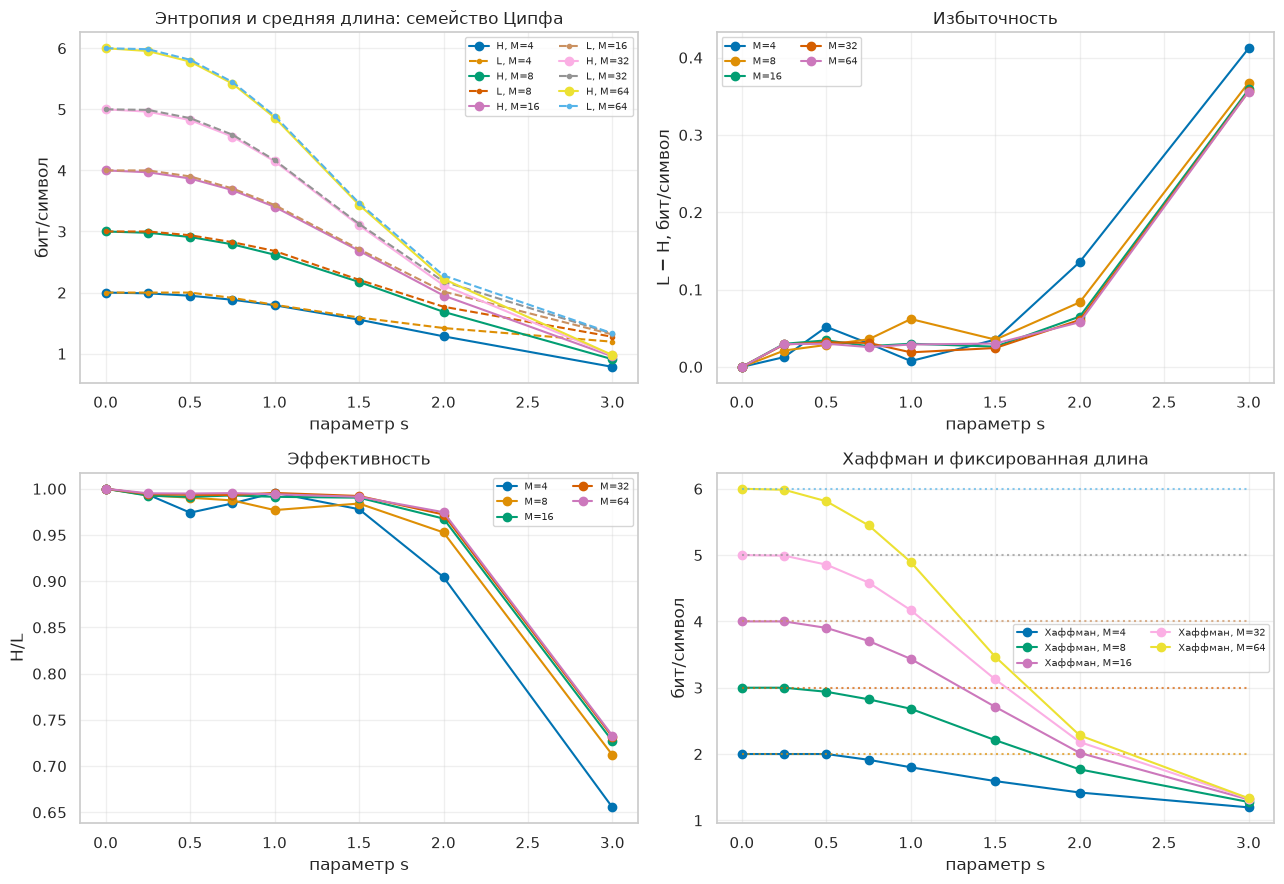

Спирменовская корреляция неравномерности с R: диапазон -1.000…0.929.


In [5]:
zipf = exp1[exp1["семейство"] == "Ципф"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for M in [4, 8, 16, 32, 64]:
    d = zipf[zipf.M == M]
    axes[0,0].plot(d.параметр, d.H, marker="o", label=f"H, M={M}")
    axes[0,0].plot(d.параметр, d.L, marker=".", linestyle="--", label=f"L, M={M}")
    axes[0,1].plot(d.параметр, d.R, marker="o", label=f"M={M}")
    axes[1,0].plot(d.параметр, d.эффективность, marker="o", label=f"M={M}")
    axes[1,1].plot(d.параметр, d.L, marker="o", label=f"Хаффман, M={M}")
    axes[1,1].plot(d.параметр, d.fixed, linestyle=":", alpha=.7)
axes[0,0].set(title="Энтропия и средняя длина: семейство Ципфа", xlabel="параметр s", ylabel="бит/символ")
axes[0,1].set(title="Избыточность", xlabel="параметр s", ylabel="L − H, бит/символ")
axes[1,0].set(title="Эффективность", xlabel="параметр s", ylabel="H/L")
axes[1,1].set(title="Хаффман и фиксированная длина", xlabel="параметр s", ylabel="бит/символ")
for ax in axes.flat: ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

# Проверка отношения избыточности к неравномерности без навязывания монотонности
corrs = exp1.groupby(["семейство", "M"]).apply(
    lambda d: d[["неравномерность", "R"]].corr(method="spearman").iloc[0,1]
    if d["неравномерность"].nunique() > 1 else np.nan,
    include_groups=False).dropna()
print(f"Спирменовская корреляция неравномерности с R: диапазон {corrs.min():.3f}…{corrs.max():.3f}.")

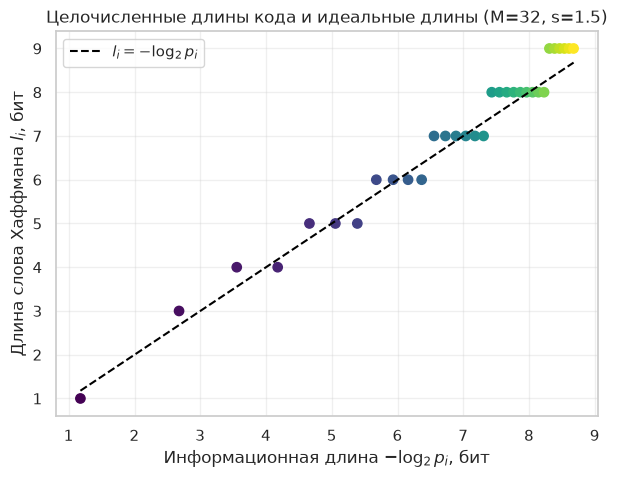

**Наблюдение.** Наибольшая экономия в рассчитанной сетке — **4.667 бит/символ**
(Ципф, $M=64$). Избыточность не обязана монотонно уменьшаться или расти с
неравномерностью: ранговые корреляции по сериям лежат в диапазоне **-1.000…0.929**.
Это связано с дискретными перестройками целочисленного дерева.

In [6]:
# Длины слов против идеальных информационных длин на одном показательном распределении
p_demo = distribution("Ципф", 32, 1.5, rng)
_, cb_demo, _ = code_for_probabilities(p_demo)
ideal = -np.log2(p_demo)
actual = np.array([len(cb_demo[i]) for i in range(len(p_demo))])
plt.figure(figsize=(7,5))
plt.scatter(ideal, actual, c=np.arange(len(p_demo)), cmap="viridis", s=45)
lo, hi = ideal.min(), ideal.max()
plt.plot([lo, hi], [lo, hi], "--", color="black", label="$l_i=-\\log_2p_i$")
plt.xlabel("Информационная длина $-\\log_2 p_i$, бит")
plt.ylabel("Длина слова Хаффмана $l_i$, бит")
plt.title("Целочисленные длины кода и идеальные длины (M=32, s=1.5)")
plt.legend(); plt.grid(True, alpha=.3); plt.show()

best_saving = exp1.loc[exp1.экономия.idxmax()]
display(Markdown(f"""**Наблюдение.** Наибольшая экономия в рассчитанной сетке — **{best_saving.экономия:.3f} бит/символ**
({best_saving.семейство}, $M={int(best_saving.M)}$). Избыточность не обязана монотонно уменьшаться или расти с
неравномерностью: ранговые корреляции по сериям лежат в диапазоне **{corrs.min():.3f}…{corrs.max():.3f}**.
Это связано с дискретными перестройками целочисленного дерева."""))

## 5. Эксперимент 2. Оценка вероятностей по конечной выборке

Полный алфавит из 16 символов известен заранее. Поэтому даже символ с нулевой частотой включается в дерево с нулевым весом. Сравниваются несглаженная оценка и оценка $(n_i+0.5)/(N+0.5M)$. Качество всегда вычисляется **по истинному распределению**, а не по обучающей выборке. Для каждого $N$ выполняется 120 независимых повторений; это даёт устойчивые оценки при умеренном времени выполнения. Oracle-код строится по истинным вероятностям. Отличие кодов сравнивается по векторам длин, поскольку при равных весах сами битовые слова не уникальны.

In [7]:
M2 = 16
true_sources = {
    "близкое к равномерному": distribution("Ципф", M2, 0.25, rng),
    "умеренный Ципф": distribution("Ципф", M2, 1.0, rng),
    "сильно неравномерное": distribution("Геометрическое", M2, 0.55, rng),
}
Ns = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
REPS2 = 120
rows = []
exp2_rng = np.random.default_rng(SEED + 1)
oracle_info = {}
for name, p in true_sources.items():
    _, oracle_cb, _ = code_for_probabilities(p)
    oracle_L = sum(p[i] * len(oracle_cb[i]) for i in range(M2))
    oracle_lengths = tuple(len(oracle_cb[i]) for i in range(M2))
    oracle_info[name] = (entropy(p), oracle_L)
    for N in Ns:
        for rep in range(REPS2):
            counts = np.bincount(exp2_rng.choice(M2, N, p=p), minlength=M2)
            for method, alpha in [("без сглаживания", 0.0), ("α=0.5", 0.5)]:
                est = (counts + alpha) / (N + alpha * M2)
                _, cb, _ = code_for_probabilities(est)
                L = sum(p[i] * len(cb[i]) for i in range(M2))
                lengths = tuple(len(cb[i]) for i in range(M2))
                rows.append([name, N, rep, method, L-oracle_L, lengths != oracle_lengths,
                             np.count_nonzero(counts == 0)])
exp2 = pd.DataFrame(rows, columns=["источник", "N", "повтор", "метод", "delta_L", "длины_отличаются", "нулевых"])
summary2 = exp2.groupby(["источник", "метод", "N"], as_index=False).agg(
    mean_delta=("delta_L", "mean"), median_delta=("delta_L", "median"),
    sd_delta=("delta_L", "std"), different_rate=("длины_отличаются", "mean"),
    mean_unseen=("нулевых", "mean"))
summary2["ci95"] = 1.96 * summary2.sd_delta / math.sqrt(REPS2)
assert (exp2.delta_L >= -1e-12).all()
display(summary2.round(4))

,источник,метод,N,mean_delta,median_delta,sd_delta,different_rate,mean_unseen,ci95
0,близкое к равномерному,α=0.5,50,0.1891,0.1802,0.0853,1.0000,0.7000,0.0153
1,близкое к равномерному,α=0.5,100,0.1017,0.0937,0.0518,1.0000,0.0167,0.0093
2,близкое к равномерному,α=0.5,200,0.0525,0.0506,0.0321,0.9750,0.0000,0.0057
3,близкое к равномерному,α=0.5,500,0.0181,0.0130,0.0180,0.8667,0.0000,0.0032
4,близкое к равномерному,α=0.5,1000,0.0087,0.0054,0.0094,0.8500,0.0000,0.0017
5,близкое к равномерному,α=0.5,2000,0.0042,0.0034,0.0044,0.7750,0.0000,0.0008
6,близкое к равномерному,α=0.5,5000,0.0023,0.0017,0.0023,0.6833,0.0000,0.0004
7,близкое к равномерному,α=0.5,10000,0.0013,0.0008,0.0016,0.5667,0.0000,0.0003
8,близкое к равномерному,без сглаживания,50,0.2532,0.2323,0.1271,1.0000,0.7000,0.0227
9,близкое к равномерному,без сглаживания,100,0.1069,0.0975,0.0530,1.0000,0.0167,0.0095


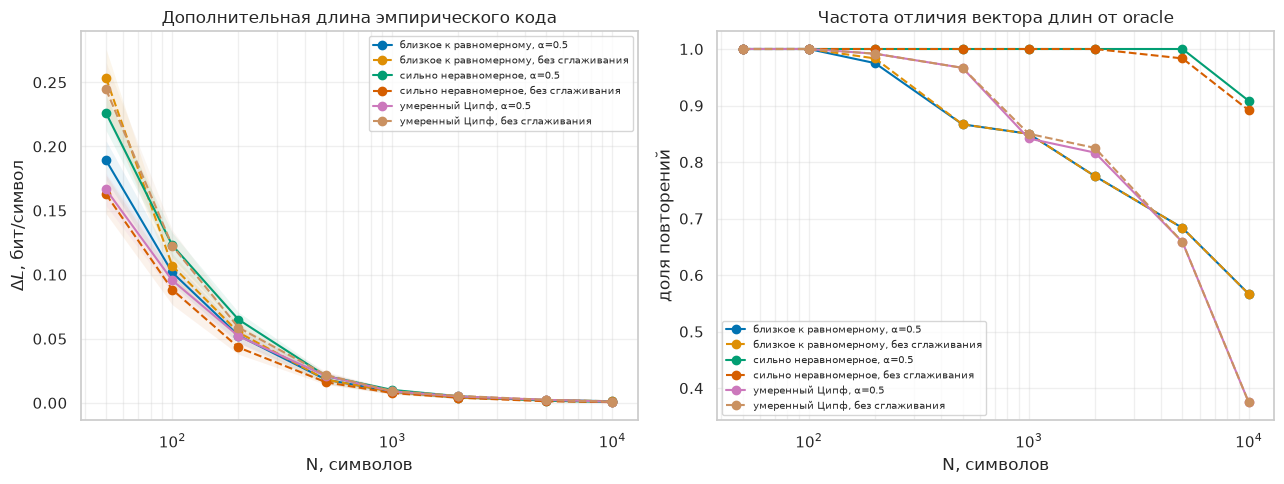

**Фактическая сходимость.** При сглаживании среднее $\Delta L$ изменилось от близкое к равномерному: 0.1891 до 0.0013; сильно неравномерное: 0.2259 до 0.0006; умеренный Ципф: 0.1664 до 0.0009 бит/символ (от $N=50$ к $N=10000$). Нулевая или почти нулевая разность возможна, когда дерево уже имеет oracle-вектор длин.

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (source, method), d in summary2.groupby(["источник", "метод"]):
    style = "-" if method == "α=0.5" else "--"
    axes[0].plot(d.N, d.mean_delta, style, marker="o", label=f"{source}, {method}")
    axes[0].fill_between(d.N, d.mean_delta-d.ci95, d.mean_delta+d.ci95, alpha=.08)
    axes[1].plot(d.N, d.different_rate, style, marker="o", label=f"{source}, {method}")
for ax in axes:
    ax.set_xscale("log"); ax.grid(True, which="both", alpha=.3); ax.legend(fontsize=7)
axes[0].set(title="Дополнительная длина эмпирического кода", xlabel="N, символов", ylabel="$\\Delta L$, бит/символ")
axes[1].set(title="Частота отличия вектора длин от oracle", xlabel="N, символов", ylabel="доля повторений")
plt.tight_layout(); plt.show()

first_last = summary2[summary2.метод == "α=0.5"].pivot(index="источник", columns="N", values="mean_delta")
display(Markdown("**Фактическая сходимость.** При сглаживании среднее $\\Delta L$ изменилось от " +
    "; ".join(f"{name}: {row[Ns[0]]:.4f} до {row[Ns[-1]]:.4f}" for name, row in first_last.iterrows()) +
    " бит/символ (от $N=50$ к $N=10000$). Нулевая или почти нулевая разность возможна, когда дерево уже имеет oracle-вектор длин."))

## 6. Эксперимент 3. Блочное кодирование

Используется источник $p=(0.50,0.25,0.15,0.10)$ и полный алфавит всех $4^m$ кортежей. В варианте A вероятности произведений известны точно. В варианте B `N` означает число обучающих **блоков**; проводится 80 повторений с $\alpha=0.5$. Ошибка вероятностей измеряется как $L_1$-расстояние между эмпирическим и истинным распределениями блоков. Код оценивается по истинным вероятностям, поэтому редкие блоки не исчезают из теста.

In [9]:
base_p = np.array([0.50, 0.25, 0.15, 0.10])
H_base = entropy(base_p)

def block_alphabet_probabilities(p, m):
    blocks = list(itertools.product(range(len(p)), repeat=m))
    probs = np.array([np.prod([p[x] for x in block]) for block in blocks])
    return blocks, probs

rowsA, block_cache = [], {}
for m in [1,2,3,4]:
    blocks, bp = block_alphabet_probabilities(base_p, m)
    _, cb, _ = code_for_probabilities(bp, blocks)
    Lm = sum(bp[i] * len(cb[b]) for i,b in enumerate(blocks))
    block_cache[m] = (blocks, bp, Lm)
    rowsA.append([m, len(blocks), entropy(bp), Lm, Lm/m, Lm/m-H_base, 1/m])
block_oracle = pd.DataFrame(rowsA, columns=["m", "число блоков", "H_блока", "L_блока", "бит/символ", "R/символ", "граница 1/m"])
assert np.all(block_oracle["бит/символ"] + 1e-12 >= H_base)
assert np.all(block_oracle["бит/символ"] < H_base + 1/block_oracle.m)
display(block_oracle.round(5))

,m,число блоков,H_блока,L_блока,бит/символ,R/символ,граница 1/m
0,1,4,1.7427,1.7500,1.7500,0.0073,1.0000
1,2,16,3.4855,3.5000,1.7500,0.0073,0.5000
2,3,64,5.2282,5.2465,1.7488,0.0061,0.3333
3,4,256,6.9710,6.9926,1.7482,0.0054,0.2500


In [10]:
block_Ns = [100, 300, 1000, 3000, 10000]
REPS3 = 80
rowsB = []
exp3_rng = np.random.default_rng(SEED + 2)
for m in [1,2,3,4]:
    blocks, bp, oracle_Lm = block_cache[m]
    K = len(blocks)
    for N in block_Ns:
        for rep in range(REPS3):
            counts = np.bincount(exp3_rng.choice(K, N, p=bp), minlength=K)
            est = (counts + 0.5) / (N + 0.5*K)
            _, cb, _ = code_for_probabilities(est, blocks)
            Lm = sum(bp[i] * len(cb[b]) for i,b in enumerate(blocks))
            rowsB.append([m, N, rep, np.mean(counts == 0), np.abs(est-bp).sum(),
                          Lm/m, (Lm-oracle_Lm)/m])
exp3 = pd.DataFrame(rowsB, columns=["m", "N", "повтор", "доля_невидимых", "L1_ошибка", "бит_на_символ", "сверх_oracle"])
summary3 = exp3.groupby(["m","N"], as_index=False).mean(numeric_only=True)
best_m = summary3.loc[summary3.groupby("N").бит_на_символ.idxmin(), ["N","m","бит_на_символ"]]
display(summary3.round(5))
display(best_m.rename(columns={"m":"лучший m"}).round(5))

,m,N,повтор,доля_невидимых,L1_ошибка,бит_на_символ,сверх_oracle
0,1,100,39.5000,0.0000,0.1201,1.7569,0.0069
1,1,300,39.5000,0.0000,0.0729,1.7512,0.0013
2,1,1000,39.5000,0.0000,0.0388,1.7500,0.0000
3,1,3000,39.5000,0.0000,0.0237,1.7500,0.0000
4,1,10000,39.5000,0.0000,0.0136,1.7500,0.0000
5,2,100,39.5000,0.0695,0.2631,1.8006,0.0506
6,2,300,39.5000,0.0039,0.1498,1.7649,0.0149
7,2,1000,39.5000,0.0000,0.0883,1.7539,0.0039
8,2,3000,39.5000,0.0000,0.0496,1.7512,0.0012
9,2,10000,39.5000,0.0000,0.0287,1.7504,0.0004


,N,лучший m,бит_на_символ
0,100,1,1.7569
1,300,1,1.7512
2,1000,1,1.7500
3,3000,1,1.7500
14,10000,3,1.7498


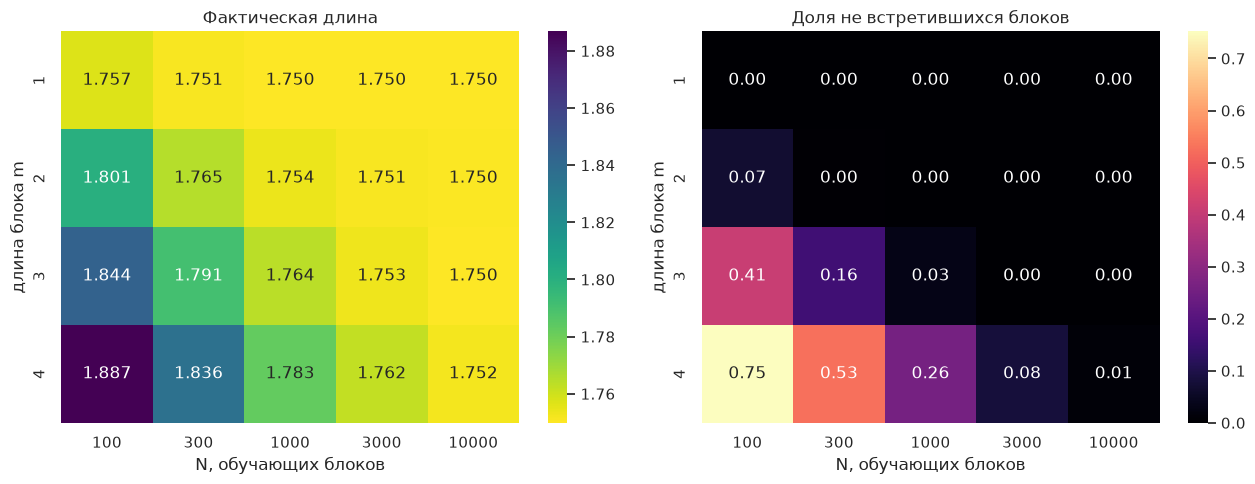

**Компромисс.** При точных вероятностях длина изменилась с
**1.7500** до **1.7481 бит/символ**.
По оценкам из данных лучший блок при $N=100$ — $m=1$, а при $N=10000$ —
$m=3$. Тепловая карта показывает, связывается ли проигрыш крупных блоков с долей невидимых комбинаций.

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pivot_bits = summary3.pivot(index="m", columns="N", values="бит_на_символ")
pivot_unseen = summary3.pivot(index="m", columns="N", values="доля_невидимых")
sns.heatmap(pivot_bits, annot=True, fmt=".3f", cmap="viridis_r", ax=axes[0])
sns.heatmap(pivot_unseen, annot=True, fmt=".2f", cmap="magma", ax=axes[1])
axes[0].set(title="Фактическая длина", xlabel="N, обучающих блоков", ylabel="длина блока m")
axes[1].set(title="Доля не встретившихся блоков", xlabel="N, обучающих блоков", ylabel="длина блока m")
plt.tight_layout(); plt.show()

small = best_m.iloc[0]; large = best_m.iloc[-1]
display(Markdown(f"""**Компромисс.** При точных вероятностях длина изменилась с
**{block_oracle.iloc[0]['бит/символ']:.4f}** до **{block_oracle.iloc[-1]['бит/символ']:.4f} бит/символ**.
По оценкам из данных лучший блок при $N={int(small.N)}$ — $m={int(small.m)}$, а при $N={int(large.N)}$ —
$m={int(large.m)}$. Тепловая карта показывает, связывается ли проигрыш крупных блоков с долей невидимых комбинаций."""))

## 7. Эксперимент 4. Реальные текстовые данные и стоимость заголовка

Корпуса встроены непосредственно в ноутбук, поэтому опыт полностью офлайн. Анализируются UTF-8 **байты**. Русский текст, английский текст и код повторяются для получения корпусов достаточной длины; контроль — равномерные случайные байты того же порядка. Побайтовая энтропия учитывает лишь частоты отдельных байтов, но не зависимости соседей. Поэтому `zlib`, использующий повторяющиеся фрагменты и контекст, приведён только как справочное сравнение.

Модель заголовка: сериализация полного двоичного дерева в прямом обходе использует по 1 маркерному биту на каждый из $2K-1$ узлов, по $b$ бит на каждый из $K$ листьев и 64 бита для длины исходного сообщения:
$$B_{header}=(2K-1)+bK+64.$$
Для байтов $b=8$, поэтому $B_{header}=10K+63$. Это конкретная учебная модель, а не универсальный формат архивного файла. Полезная нагрузка вычисляется точно по целым частотам, а последний байт на диске потребовал бы дополнительного округления до 8 бит.

In [12]:
ru_base = """Теория информации изучает количественные меры неопределённости и передачи сообщений. Код Хаффмана назначает короткие слова частым символам и длинные слова редким. Эксперимент позволяет увидеть границы теоремы и влияние конечной выборки. """
en_base = """Information theory studies uncertainty, coding, and reliable communication. Huffman coding assigns shorter words to frequent symbols and longer words to rare ones. Reproducible experiments connect mathematical bounds with practical compression. """
code_base = """def huffman(weights):
    heap = [(w, i, symbol) for i, (symbol, w) in enumerate(weights.items())]
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        # combine the two lightest nodes
        heapq.heappush(heap, (left[0] + right[0], len(heap), (left, right)))
    return heap[0]
"""
corpora = {
    "русский текст": (ru_base * 120).encode("utf-8"),
    "английский текст": (en_base * 120).encode("utf-8"),
    "программный код": (code_base * 120).encode("utf-8"),
    "случайные байты": np.random.default_rng(SEED).integers(0, 256, 30000, dtype=np.uint8).tobytes(),
}

def header_bits(K, symbol_bits=8, length_bits=64):
    return (2*K - 1) + symbol_bits*K + length_bits

text_rows = []
for name, data in corpora.items():
    counts = Counter(data); n = len(data); K = len(counts)
    p = {s: c/n for s,c in counts.items()}
    tree = build_huffman_tree(counts); cb = build_codebook(tree)
    H = entropy(p.values()); L = average_code_length(p, cb)
    payload = sum(counts[s] * len(cb[s]) for s in counts)
    fixed = 8*n; header = header_bits(K)
    total = payload + header
    text_rows.append([name, n, K, H, L, payload, fixed, payload/fixed,
                      header, total, total/fixed, len(zlib.compress(data))*8])
texts = pd.DataFrame(text_rows, columns=["корпус", "байт", "различных байтов", "H, бит/байт",
    "L, бит/байт", "payload, бит", "fixed, бит", "коэф. без заголовка", "header, бит",
    "total, бит", "коэф. с заголовком", "zlib, бит"])
assert (texts["L, бит/байт"] + 1e-12 >= texts["H, бит/байт"]).all()
display(texts.round(4))

,корпус,байт,различных байтов,"H, бит/байт","L, бит/байт","payload, бит","fixed, бит",коэф. без заголовка,"header, бит","total, бит",коэф. с заголовком,"zlib, бит"
0,русский текст,53040,35,3.7382,3.7851,200760,424320,0.4731,413,201173,0.4741,4168
1,английский текст,29400,28,4.2838,4.3102,126720,235200,0.5388,343,127063,0.5402,2480
2,программный код,39840,36,4.3695,4.4096,175680,318720,0.5512,423,176103,0.5525,3144
3,случайные байты,30000,256,7.9939,8.0000,240000,240000,1.0000,2623,242623,1.0109,240128


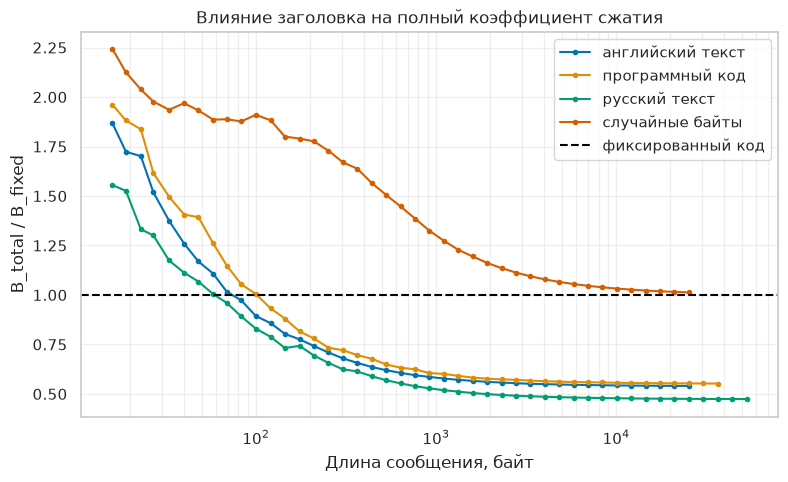

,корпус,"первый выигрыш в сетке, байт"
0,английский текст,83.0000
1,программный код,121.0000
2,русский текст,69.0000
3,случайные байты,NaN


In [13]:
# Окупаемость заголовка при префиксах каждого корпуса
length_grid = np.unique(np.geomspace(16, max(map(len, corpora.values())), 45).astype(int))
curve_rows = []
for name, data in corpora.items():
    for n in length_grid[length_grid <= len(data)]:
        sample = data[:n]; counts = Counter(sample); K = len(counts)
        cb = build_codebook(build_huffman_tree(counts))
        payload = sum(c*len(cb[s]) for s,c in counts.items())
        total = payload + header_bits(K)
        curve_rows.append([name, n, total/(8*n), payload, total, K])
curves = pd.DataFrame(curve_rows, columns=["корпус","байт","полный коэффициент","payload","total","K"])

thresholds = []
for name, d in curves.groupby("корпус"):
    wins = d[d["полный коэффициент"] < 1]
    thresholds.append([name, int(wins.байт.min()) if len(wins) else np.nan])
thresholds = pd.DataFrame(thresholds, columns=["корпус", "первый выигрыш в сетке, байт"])

plt.figure(figsize=(9,5))
for name, d in curves.groupby("корпус"):
    plt.plot(d.байт, d["полный коэффициент"], marker=".", label=name)
plt.axhline(1, color="black", linestyle="--", label="фиксированный код")
plt.xscale("log"); plt.xlabel("Длина сообщения, байт"); plt.ylabel("B_total / B_fixed")
plt.title("Влияние заголовка на полный коэффициент сжатия")
plt.legend(); plt.grid(True, which="both", alpha=.3); plt.show()
display(thresholds)

## 8. Итоговые таблицы и обсуждение

Следующие компактные таблицы собирают главные результаты. Для распределений показаны средние по всей исследованной сетке параметров; для выборок — сглаженный метод; для блоков — точный oracle-вариант; порог заголовка является первым выигрышным размером **на логарифмической сетке**, а не точной универсальной константой.

In [14]:
family_final = exp1.groupby("семейство", as_index=False).agg(
    H=("H","mean"), L=("L","mean"), R=("R","mean"),
    эффективность=("эффективность","mean"), экономия=("экономия","mean"))
sample_final = summary2[(summary2.метод == "α=0.5") & summary2.N.isin([50, 1000, 10000])][
    ["источник","N","mean_delta","median_delta","ci95","different_rate"]]
display(Markdown("### Сравнение семейств распределений")); display(family_final.round(4))
display(Markdown("### Влияние обучающей выборки")); display(sample_final.round(4))
display(Markdown("### Блочное кодирование при известных вероятностях")); display(block_oracle.round(5))
display(Markdown("### Реальные данные")); display(texts.round(4))
display(Markdown("### Окупаемость заголовка")); display(thresholds)

### Сравнение семейств распределений

,семейство,H,L,R,эффективность,экономия
0,Геометрическое,2.9822,3.0061,0.0239,0.9916,0.9939
1,Дирихле,3.1469,3.2467,0.0998,0.9316,0.7533
2,Равномерное,4.0000,4.0000,0.0000,1.0000,0.0000
3,Ципф,3.0287,3.1037,0.0750,0.9521,0.8963


### Влияние обучающей выборки

,источник,N,mean_delta,median_delta,ci95,different_rate
0,близкое к равномерному,50,0.1891,0.1802,0.0153,1.0000
4,близкое к равномерному,1000,0.0087,0.0054,0.0017,0.8500
7,близкое к равномерному,10000,0.0013,0.0008,0.0003,0.5667
16,сильно неравномерное,50,0.2259,0.2277,0.0136,1.0000
20,сильно неравномерное,1000,0.0101,0.0085,0.0012,1.0000
23,сильно неравномерное,10000,0.0006,0.0005,0.0001,0.9083
32,умеренный Ципф,50,0.1664,0.1502,0.0128,1.0000
36,умеренный Ципф,1000,0.0090,0.0067,0.0014,0.8417
39,умеренный Ципф,10000,0.0009,0.0000,0.0003,0.3750


### Блочное кодирование при известных вероятностях

,m,число блоков,H_блока,L_блока,бит/символ,R/символ,граница 1/m
0,1,4,1.7427,1.7500,1.7500,0.0073,1.0000
1,2,16,3.4855,3.5000,1.7500,0.0073,0.5000
2,3,64,5.2282,5.2465,1.7488,0.0061,0.3333
3,4,256,6.9710,6.9926,1.7482,0.0054,0.2500


### Реальные данные

,корпус,байт,различных байтов,"H, бит/байт","L, бит/байт","payload, бит","fixed, бит",коэф. без заголовка,"header, бит","total, бит",коэф. с заголовком,"zlib, бит"
0,русский текст,53040,35,3.7382,3.7851,200760,424320,0.4731,413,201173,0.4741,4168
1,английский текст,29400,28,4.2838,4.3102,126720,235200,0.5388,343,127063,0.5402,2480
2,программный код,39840,36,4.3695,4.4096,175680,318720,0.5512,423,176103,0.5525,3144
3,случайные байты,30000,256,7.9939,8.0000,240000,240000,1.0000,2623,242623,1.0109,240128


### Окупаемость заголовка

,корпус,"первый выигрыш в сетке, байт"
0,английский текст,83.0000
1,программный код,121.0000
2,русский текст,69.0000
3,случайные байты,NaN


### Интерпретация и ограничения

Энтропия — нижняя граница средней длины префиксного кода из-за ограничения Крафта: доступное «пространство» листьев двоичного дерева нельзя распределить лучше идеальных вероятностных длин. Хаффман оптимизирует целочисленные глубины листьев, но $-\log_2p_i$ обычно нецелое; блоки делят максимум один лишний бит на $m$ исходных символов. При конечной выборке порядок оценённых весов меняется, а редкие события могут отсутствовать, что перестраивает дерево и добавляет статистическую избыточность.

Практический файл отличается от $nL$: нужны дерево/таблица, длина сообщения, упаковка последнего байта и метаданные формата. Здесь учтена одна прозрачная модель дерева, но не выравнивание, контроль целостности и контейнер. Посимвольная модель также игнорирует зависимости; `zlib` не является прямым конкурентом в теоретическом опыте, потому что использует повторения.

Ограничения: источники считаются стационарными; блоки — независимыми неперекрывающимися объектами; исследованы конечные сетки $M,m,N$; Дирихле представлен 12 реализациями, выборочные опыты — 120 и 80 повторениями; корпус встроенный и сравнительно небольшой. Поэтому численные пороги характеризуют эти условия, тогда как теоретические границы имеют общий характер.

## 9. Заключение

Итог ниже формируется из реально рассчитанных таблиц. Формулировки «в исследованном диапазоне» не экстраполируют результат за пределы сетки параметров.

In [15]:
# Автоматически вычисляем факты, на которых основаны решения по гипотезам.
max_bound_gap = float((exp1.L - exp1.H).max())
uniform_saving = float(exp1[exp1.семейство == "Равномерное"].экономия.mean())
skew_saving = float(exp1[exp1.неравномерность >= exp1.неравномерность.quantile(.9)].экономия.mean())

conv = first_last
converged_count = int((conv[Ns[-1]] <= conv[Ns[0]] + 1e-12).sum())

oracle_first = float(block_oracle.iloc[0]["R/символ"])
oracle_last = float(block_oracle.iloc[-1]["R/символ"])
large_m_hurts = bool((summary3.pivot(index="N", columns="m", values="бит_на_символ")[4] >
                      summary3.pivot(index="N", columns="m", values="бит_на_символ").min(axis=1) + 1e-10).any())

finite_thresholds = thresholds["первый выигрыш в сетке, байт"].dropna()
threshold_text = ", ".join(f"{r['корпус']}: {int(r['первый выигрыш в сетке, байт'])} байт"
                           for _, r in thresholds.dropna().iterrows())
no_win = ", ".join(thresholds.loc[thresholds.iloc[:,1].isna(), "корпус"])

conclusion = f"""
1. **Подтверждена в исследованном диапазоне.** Во всех {len(exp1)} синтетических случаях выполнено
   $H\\le L<H+1$; максимальное наблюдаемое $L-H={max_bound_gap:.4f}$ бит/символ. Проверки реализации также прошли.
2. **Подтверждена частично.** Средняя экономия равномерных источников составила {uniform_saving:.4f}, а у 10% наиболее
   неравномерных случаев — {skew_saving:.4f} бит/символ. Однако сама избыточность $L-H$ не монотонна:
   ранговые корреляции в отдельных сериях лежат от {corrs.min():.3f} до {corrs.max():.3f}.
3. **Подтверждена в исследованном диапазоне.** Для {converged_count} из {len(conv)} источников среднее $\\Delta L$
   при сглаживании к $N=10000$ не выше значения при $N=50$; конечные значения: """ + ", ".join(
       f"{name} — {row[Ns[-1]]:.4f}" for name,row in conv.iterrows()) + " бит/символ.\n" + f"""
4. **Подтверждена в исследованном диапазоне.** Все $m=1,2,3,4$ удовлетворили
   $H\\le L_m/m<H+1/m$; фактическая избыточность изменилась с {oracle_first:.4f} до {oracle_last:.4f} бит/символ.
5. **{'Подтверждена' if large_m_hurts else 'Не подтверждена'} в исследованном диапазоне.**
   Для хотя бы одного объёма данных $m=4$ {'не был' if large_m_hurts else 'был'} лучшим; оптимальные $m$ по $N$:
   """ + ", ".join(f"{int(r.N)}→{int(r.m)}" for _,r in best_m.iterrows()) + ".\n" + f"""
6. **Подтверждена в исследованном диапазоне.** На коротких префиксах заголовок повышал полный коэффициент;
   первый выигрыш на использованной сетке: {threshold_text or 'не найден'}.
   {('Не дал выигрыша в доступном диапазоне: ' + no_win + '.') if no_win else ''}

Итак, работа воспроизводит классические границы Хаффмана и показывает, что практический выбор кода определяется не
только энтропией: важны ошибки оценивания, размер пространства блоков и формат метаданных. Это самостоятельное
вычислительное исследование известных свойств, а не заявление о новом научном открытии.
"""
display(Markdown(conclusion))


1. **Подтверждена в исследованном диапазоне.** Во всех 365 синтетических случаях выполнено
   $H\le L<H+1$; максимальное наблюдаемое $L-H=0.9690$ бит/символ. Проверки реализации также прошли.
2. **Подтверждена частично.** Средняя экономия равномерных источников составила 0.0000, а у 10% наиболее
   неравномерных случаев — 1.8336 бит/символ. Однако сама избыточность $L-H$ не монотонна:
   ранговые корреляции в отдельных сериях лежат от -1.000 до 0.929.
3. **Подтверждена в исследованном диапазоне.** Для 3 из 3 источников среднее $\Delta L$
   при сглаживании к $N=10000$ не выше значения при $N=50$; конечные значения: близкое к равномерному — 0.0013, сильно неравномерное — 0.0006, умеренный Ципф — 0.0009 бит/символ.

4. **Подтверждена в исследованном диапазоне.** Все $m=1,2,3,4$ удовлетворили
   $H\le L_m/m<H+1/m$; фактическая избыточность изменилась с 0.0073 до 0.0054 бит/символ.
5. **Подтверждена в исследованном диапазоне.**
   Для хотя бы одного объёма данных $m=4$ не был лучшим; оптимальные $m$ по $N$:
   100→1, 300→1, 1000→1, 3000→1, 10000→3.

6. **Подтверждена в исследованном диапазоне.** На коротких префиксах заголовок повышал полный коэффициент;
   первый выигрыш на использованной сетке: английский текст: 83 байт, программный код: 121 байт, русский текст: 69 байт.
   Не дал выигрыша в доступном диапазоне: случайные байты.

Итак, работа воспроизводит классические границы Хаффмана и показывает, что практический выбор кода определяется не
только энтропией: важны ошибки оценивания, размер пространства блоков и формат метаданных. Это самостоятельное
вычислительное исследование известных свойств, а не заявление о новом научном открытии.


In [16]:
# Финальные инварианты воспроизводимого запуска
assert len(exp1) > 100 and len(exp2) == 3 * 8 * REPS2 * 2
assert len(exp3) == 4 * 5 * REPS3
assert not any(df.isna().any().any() for df in [exp1, exp2, summary2, block_oracle, exp3, summary3, texts])
assert (texts["payload, бит"] <= texts["fixed, бит"]).all()
print("Финальная проверка завершена: исключений нет, все assert выполнены, результаты получены из расчётов.")

Финальная проверка завершена: исключений нет, все assert выполнены, результаты получены из расчётов.
